Libraries imported.
Dataset loaded. Shape: (145460, 23)


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


After sampling: (10000, 23)
After cleaning: (9760, 23)
After feature engineering. Columns: ['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow', 'Year', 'Month', 'Day']
After encoding. Shape: (9760, 114)
Train shape: (7808, 113)
Test shape: (1952, 113)
Scaling done.

=== Linear Regression ===
MAE  : 0.6756
RMSE : 0.9221
R²   : 0.9802

=== KNN (k=5) ===
MAE  : 2.9466
RMSE : 3.8075
R²   : 0.6621

Starting GridSearch for Random Forest...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best RF Params: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

=== Random Forest (Train) ===
MAE  : 0.3049
RMSE : 0.5065
R²   : 0.9948

=== Random Forest (Test) ===
MAE  : 0.6666
RMSE : 0.9629
R²   : 0.9784

=== 

,Model,MAE,RMSE,R²
0,Linear Regression,0.675650,0.922111,0.980179
1,KNN (k=5),2.946629,3.807525,0.662064
2,Random Forest (Tuned),0.666646,0.962872,0.978388


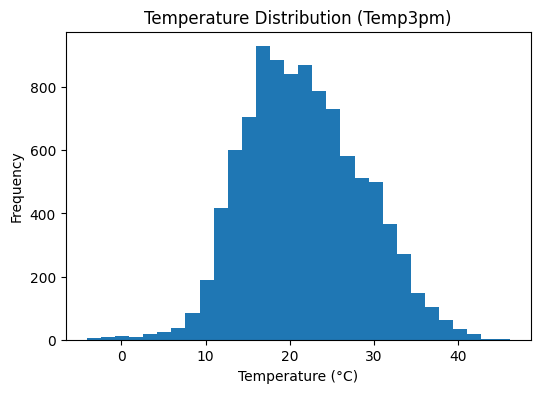

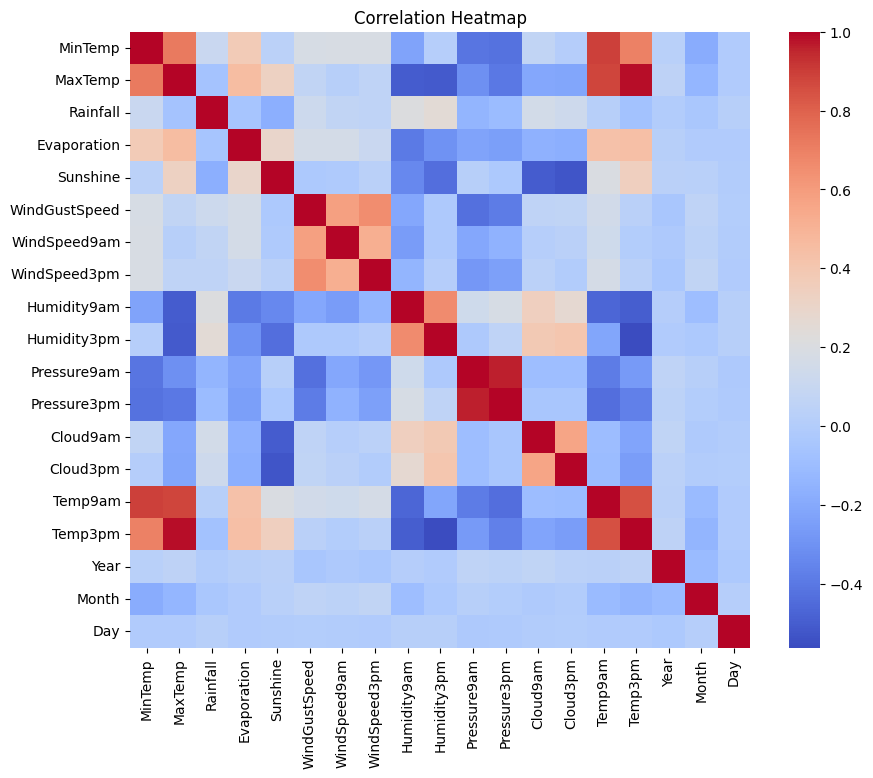

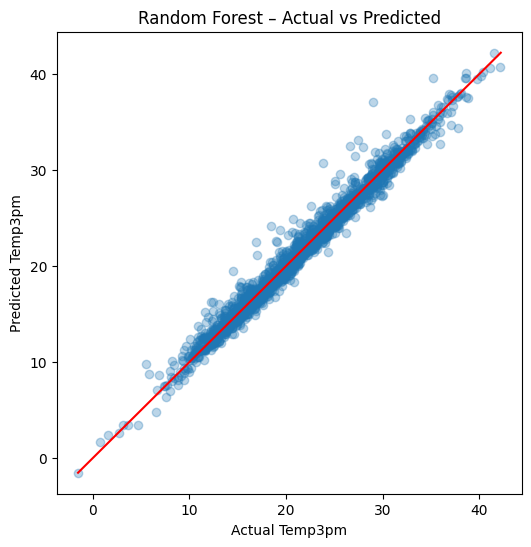

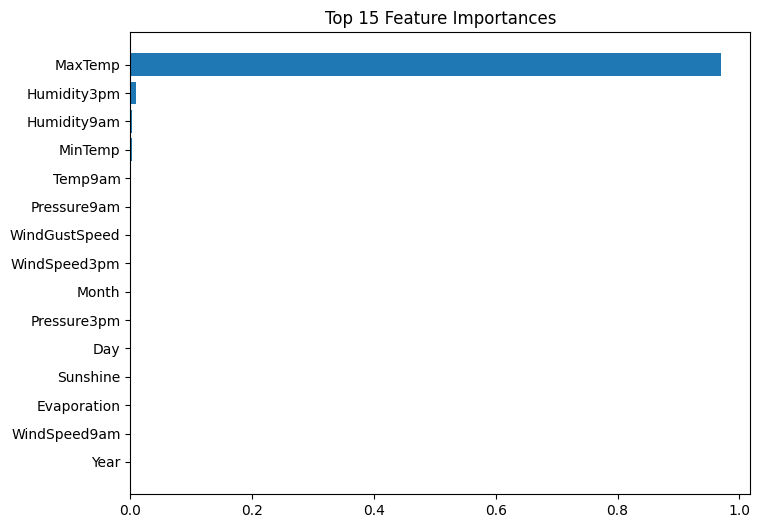

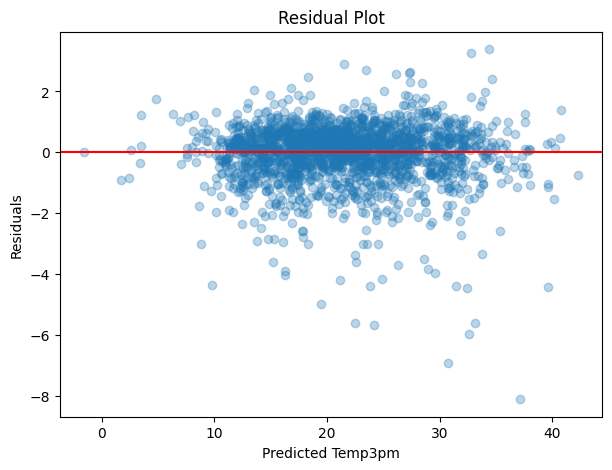


=== Predicted Temp3pm for Next 5 Days ===
Day 1: -2.22 °C
Day 2: -2.15 °C
Day 3: -1.35 °C
Day 4: -1.31 °C
Day 5: -1.63 °C


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [1]:
# ============================================
# 1) Import Libraries
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

print("Libraries imported.")


# ============================================
# 2) Load Dataset
# ============================================
DATA_PATH = "/kaggle/input/wther-sa/weatherAUS.csv"

df = pd.read_csv(DATA_PATH)
print("Dataset loaded. Shape:", df.shape)
display(df.head())


# ============================================
# 3) (Optional) Sample for speed
# ============================================
df = df.sample(10000, random_state=42)
print("After sampling:", df.shape)


# ============================================
# 4) Basic Cleaning
# ============================================
df = df.dropna(subset=["Temp3pm"])

num_cols = df.select_dtypes(include=["float64", "int64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=["object"]).columns
if len(cat_cols) > 0:
    df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

print("After cleaning:", df.shape)


# ============================================
# 5) Feature Engineering (Date -> Year, Month, Day)
# ============================================
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day
    df = df.drop(columns=["Date"])

print("After feature engineering. Columns:", df.columns.tolist())


# ============================================
# 6) Encoding Categorical Features
# ============================================
df_encoded = pd.get_dummies(df, drop_first=True)
print("After encoding. Shape:", df_encoded.shape)


# ============================================
# 7) Split Features / Target
# ============================================
X = df_encoded.drop("Temp3pm", axis=1)
y = df_encoded["Temp3pm"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


# ============================================
# 8) Scaling (for Linear Regression & KNN)
# ============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done.")


# ============================================
# 9) Helper function for evaluation
# ============================================
def evaluate_regression(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    print(f"\n=== {model_name} ===")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    return mae, rmse, r2


# ============================================
# 10) Baseline Models
# ============================================
baseline_results = {}

# (1) Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
mae, rmse, r2 = evaluate_regression(y_test, y_pred_lr, "Linear Regression")
baseline_results["Linear Regression"] = {"MAE": mae, "RMSE": rmse, "R2": r2}

# (2) KNN Regressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
mae, rmse, r2 = evaluate_regression(y_test, y_pred_knn, "KNN (k=5)")
baseline_results["KNN (k=5)"] = {"MAE": mae, "RMSE": rmse, "R2": r2}


# ============================================
# 11) RandomForestRegressor + GridSearchCV
# ============================================
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

print("\nStarting GridSearch for Random Forest...")
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print("\nBest RF Params:", grid_search.best_params_)


# ============================================
# 12) Evaluate Random Forest (Train vs Test)
# ============================================

y_train_pred_rf = best_rf.predict(X_train)
train_mae, train_rmse, train_r2 = evaluate_regression(
    y_train, y_train_pred_rf, "Random Forest (Train)"
)

y_test_pred_rf = best_rf.predict(X_test)
test_mae, test_rmse, test_r2 = evaluate_regression(
    y_test, y_test_pred_rf, "Random Forest (Test)"
)

baseline_results["Random Forest (Tuned)"] = {
    "MAE": test_mae,
    "RMSE": test_rmse,
    "R2": test_r2
}


# ============================================
# 13) Models Comparison Table
# ============================================
results_table = []
for name, metrics in baseline_results.items():
    results_table.append([name, metrics["MAE"], metrics["RMSE"], metrics["R2"]])

results_df = pd.DataFrame(
    results_table,
    columns=["Model", "MAE", "RMSE", "R²"]
)
print("\n=== Models Comparison ===")
display(results_df)


# ============================================
# 14) Visualizations
# ============================================

# 14.1 Histogram
plt.figure(figsize=(6,4))
plt.hist(df["Temp3pm"], bins=30)
plt.title("Temperature Distribution (Temp3pm)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

# 14.2 Heatmap
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# 14.3 Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred_rf, alpha=0.3)
min_val = min(y_test.min(), y_test_pred_rf.min())
max_val = max(y_test.max(), y_test_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red')
plt.xlabel("Actual Temp3pm")
plt.ylabel("Predicted Temp3pm")
plt.title("Random Forest – Actual vs Predicted")
plt.show()

# 14.4 Feature Importance
importances = best_rf.feature_importances_
indices = np.argsort(importances)[-15:]

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Top 15 Feature Importances")
plt.show()

# 14.5 Residual Plot
residuals = y_test - y_test_pred_rf
plt.figure(figsize=(7,5))
plt.scatter(y_test_pred_rf, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel("Predicted Temp3pm")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


# ============================================
# 15) Predict Next Days Temperature  (ADDED)
# ============================================

n_future_days = 5  # عدد الأيام للتوقع

last_rows = df_encoded.tail(n_future_days)

X_future = last_rows.drop("Temp3pm", axis=1, errors="ignore")

try:
    X_future_scaled = scaler.transform(X_future)
    future_preds = best_rf.predict(X_future_scaled)
except:
    future_preds = best_rf.predict(X_future)

print("\n=== Predicted Temp3pm for Next 5 Days ===")
for i, temp in enumerate(future_preds, 1):
    print(f"Day {i}: {temp:.2f} °C")
